# UAS NLP - Eksperimen ABSA & NER
Domain: Review aplikasi Grab di Google Play Store (bahasa Indonesia)


In [1]:
# !pip install google-play-scraper Sastrawi nltk scikit-learn pandas numpy matplotlib seaborn joblib python-Levenshtein


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from google_play_scraper import reviews, Sort
import Levenshtein

nltk.download('punkt')
nltk.download('punkt_tab')

# Membuat direktori data dan models jika belum ada
os.makedirs('../data', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Seed untuk reproducibility
RANDOM_STATE = 42
TEST_SIZE = 0.2
np.random.seed(RANDOM_STATE)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Bagian 1: Scraping Data
Langkah ini melakukan scraping ulasan aplikasi Grab dari Google Play Store. Kami memfilter ulasan berbahasa Indonesia dan menyimpannya ke `data/raw_reviews.csv`.


In [3]:
# Scraping 500+ review dari Grab
result, continuation_token = reviews(
    'com.grabtaxi.passenger',
    lang='id', 
    country='id', 
    sort=Sort.NEWEST, 
    count=5000 
)

df_raw = pd.DataFrame(result)
df_raw = df_raw[['content', 'score']]
df_raw.rename(columns={'content': 'text'}, inplace=True)

# Menyimpan data mentah
df_raw.to_csv('../data/raw_reviews.csv', index=False)

# Menampilkan 5 sampel
display(df_raw.head())


,text,score
0,lumayan bagus,3
1,baik,5
2,good,5
3,ada salah satu driver grab luxury dengan kenda...,1
4,"Aplikasi Maxim di Nabire sangat Buruk,,, Teman...",5


EDA 1 - DATASET MENTAH (raw_reviews.csv)

1. Jumlah total review   : 5000
Jumlah kolom          : 2
Kolom                 : ['text', 'score']
Data duplikat         : 1397

Data kosong (null) per kolom:
text     0
score    0

2. Distribusi Rating (Score):
score
1    1446
2     171
3     171
4     216
5    2996

Rata-rata score : 3.63
Median score    : 5.0

3. Visualisasi Distribusi Rating:

3. Panjang Teks:


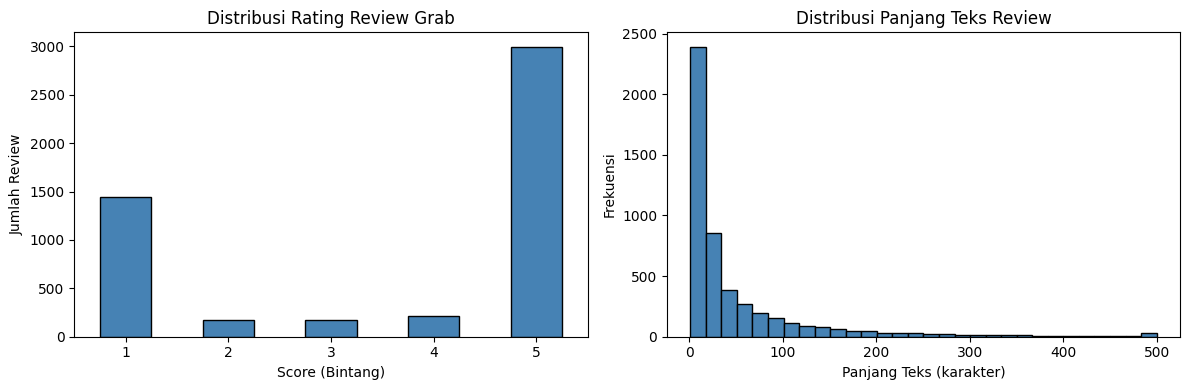


Panjang teks minimum  : 1 karakter
Panjang teks maksimum : 500 karakter
Rata-rata panjang     : 52.1 karakter

Contoh 5 Baris Data Mentah:


,text,score
0,lumayan bagus,3
1,baik,5
2,good,5
3,ada salah satu driver grab luxury dengan kenda...,1
4,"Aplikasi Maxim di Nabire sangat Buruk,,, Teman...",5


In [4]:
# ============================================================
# EDA 1 - Analisis Dataset Mentah (Setelah Scraping)
# ============================================================

print("=" * 55)
print("EDA 1 - DATASET MENTAH (raw_reviews.csv)")
print("=" * 55)

# Info dasar
print(f"\n1. Jumlah total review   : {len(df_raw)}")
print(f"Jumlah kolom          : {df_raw.shape[1]}")
print(f"Kolom                 : {list(df_raw.columns)}")
print(f"Data duplikat         : {df_raw.duplicated().sum()}")
print(f"\nData kosong (null) per kolom:")
print(df_raw.isnull().sum().to_string())

# Distribusi rating
print(f"\n2. Distribusi Rating (Score):")
print(df_raw['score'].value_counts().sort_index().to_string())
print(f"\nRata-rata score : {df_raw['score'].mean():.2f}")
print(f"Median score    : {df_raw['score'].median():.1f}")

# Visualisasi distribusi rating\
print(f"\n3. Visualisasi Distribusi Rating:")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_raw['score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Distribusi Rating Review Grab')
axes[0].set_xlabel('Score (Bintang)')
axes[0].set_ylabel('Jumlah Review')
axes[0].tick_params(axis='x', rotation=0)

# Panjang teks
print(f"\n3. Panjang Teks:")

df_raw['text_length'] = df_raw['text'].astype(str).apply(len)
axes[1].hist(df_raw['text_length'], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Distribusi Panjang Teks Review')
axes[1].set_xlabel('Panjang Teks (karakter)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print(f"\nPanjang teks minimum  : {df_raw['text_length'].min()} karakter")
print(f"Panjang teks maksimum : {df_raw['text_length'].max()} karakter")
print(f"Rata-rata panjang     : {df_raw['text_length'].mean():.1f} karakter")

# Tampilkan 5 sampel
print("\nContoh 5 Baris Data Mentah:")
display(df_raw[['text', 'score']].head())


## Bagian 2: Preprocessing
Di bagian ini, kita membersihkan teks:
1. Case folding (huruf kecil)
2. Cleaning URL, mention, simbol, angka
3. Normalisasi slang/typo menggunakan kamus sederhana
4. Tokenisasi dengan NLTK
5. Stopword removal dan Stemming dengan Sastrawi


In [5]:
# Inisialisasi Sastrawi
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()

factory_stopword = StopWordRemoverFactory()
default_stopwords = set(factory_stopword.get_stop_words())
# Kata negasi/penting yang dikecualikan agar tidak mengubah polaritas sentimen
ignored_stopwords = {'tidak', 'jangan', 'kurang', 'bukan', 'belum', 'tidaklah'}
custom_stopwords = default_stopwords - ignored_stopwords

# Kamus slang/typo (minimal 20 kata)
slang_dict = {
    'yg': 'yang', 'dgn': 'dengan', 'utk': 'untuk', 'bs': 'bisa', 'gk': 'tidak',
    'ga': 'tidak', 'gak': 'tidak', 'tdk': 'tidak', 'bgt': 'banget', 'bgs': 'bagus',
    'klo': 'kalau', 'kalo': 'kalau', 'sm': 'sama', 'dr': 'dari', 'jd': 'jadi',
    'jgn': 'jangan', 'nya': '', 'udh': 'sudah', 'sdh': 'sudah', 'tp': 'tapi',
    'drivernya': 'driver', 'aplikasinya': 'aplikasi', 'sy': 'saya', 'jg': 'juga',
    'kpd': 'kepada', 'krn': 'karena', 'bikin': 'buat'
}

def clean_text(text):
    # 1. Case folding
    text = text.lower()
    # 2. Cleaning URL, mention, simbol, angka
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_slang(text):
    words = text.split()
    normalized = [slang_dict.get(word, word) for word in words]
    return ' '.join(normalized)

def preprocess(text):
    text = clean_text(text)
    text = normalize_slang(text)
    # Stopword removal dengan custom stopword list
    words = text.split()
    filtered = [w for w in words if w not in custom_stopwords]
    text = ' '.join(filtered)
    # Stemming Sastrawi
    text = stemmer.stem(text)
    return text

# Mengaplikasikan preprocessing (menggunakan 500 sampel agar dataset lebih besar & representatif)
df_prep = df_raw.copy()
df_prep['clean_text'] = df_prep['text'].apply(preprocess)
# Tokenisasi menggunakan nltk
df_prep['tokens'] = df_prep['clean_text'].apply(nltk.word_tokenize)

# Tampilkan before-after (10 baris)
display(df_prep[['text', 'clean_text', 'tokens']].head(10))


,text,clean_text,tokens
0,lumayan bagus,lumayan bagus,"[lumayan, bagus]"
1,baik,baik,[baik]
2,good,good,[good]
3,ada salah satu driver grab luxury dengan kenda...,salah satu driver grab luxury kendara maxus na...,"[salah, satu, driver, grab, luxury, kendara, m..."
4,"Aplikasi Maxim di Nabire sangat Buruk,,, Teman...",aplikasi maxim nabire sangat buruk teman nabir...,"[aplikasi, maxim, nabire, sangat, buruk, teman..."
5,Ngambil potong gede ke driver kecil ... driver...,ngambil potong gede driver kecil driver cuma d...,"[ngambil, potong, gede, driver, kecil, driver,..."
6,sangat bagus sangat cocok untuk pergi kmna man...,sangat bagus sangat cocok pergi kmna mana sang...,"[sangat, bagus, sangat, cocok, pergi, kmna, ma..."
7,lambat,lambat,[lambat]
8,terlalu mahal,terlalu mahal,"[terlalu, mahal]"
9,sangat membantu 👍👍👍,sangat bantu,"[sangat, bantu]"


## Bagian 3: Regex / FSA
Menggunakan Regex untuk:
1. Ekstraksi kandidat aspek (kata benda seperti driver, aplikasi, harga, layanan).
2. Deteksi ekspresi rating/bintang (contoh: "bintang 5", "1 bintang").


In [6]:
def extract_aspect_candidates(text):
    # Aspek yang umum di domain transportasi/ojol
    pattern = r'\b(driver|supir|aplikasi|app|harga|ongkir|tarif|layanan|pelayanan|aman|keamanan|promo|diskon|map|peta)\b'
    matches = re.findall(pattern, text, re.IGNORECASE)
    return list(set(matches))

def detect_rating_expression(text):
    # Mendeteksi ekspresi rating
    pattern = r'\b(?:bintang\s*\d|\d\s*bintang|rate\s*\d|rating\s*\d)\b'
    matches = re.findall(pattern, text, re.IGNORECASE)
    return matches

print("Contoh Ekstraksi Aspek & Rating:")
sample_texts = [
    "driver nya ramah banget, aplikasinya juga gampang dipake, bintang 5 deh!",
    "kecewa sama harga yang makin mahal, saya kasih 1 bintang untuk app ini.",
    "banyak promo dan diskon, driver cepat sampai"
]

for t in sample_texts:
    print(f"Teks: {t}")
    print(f"Aspek: {extract_aspect_candidates(t)}")
    print(f"Rating: {detect_rating_expression(t)}\n")


Contoh Ekstraksi Aspek & Rating:
Teks: driver nya ramah banget, aplikasinya juga gampang dipake, bintang 5 deh!
Aspek: ['driver']
Rating: ['bintang 5']

Teks: kecewa sama harga yang makin mahal, saya kasih 1 bintang untuk app ini.
Aspek: ['app', 'harga']
Rating: ['1 bintang']

Teks: banyak promo dan diskon, driver cepat sampai
Aspek: ['promo', 'diskon', 'driver']
Rating: []



## Bagian 4: Representasi Teks
Di bagian ini, kita akan mengubah teks yang sudah dibersihkan ke dalam bentuk vektor numerik. Metode yang digunakan adalah:
1. Bag of Words (BoW)
2. N-Gram (Bigram)
3. TF-IDF

**Penjelasan Sparse Representation:**
Sparse representation adalah representasi matriks di mana sebagian besar elemennya bernilai nol (0). Dalam pemrosesan teks, jumlah kosakata (vocabulary) unik dalam seluruh dokumen sangat besar, tetapi setiap kalimat (dokumen) hanya mengandung sedikit kosakata tersebut. Oleh karena itu, matriks vektor teks akan dipenuhi oleh angka nol, sehingga disebut *sparse matrix*. Format ini hemat memori karena algoritma hanya menyimpan nilai yang tidak nol.


In [7]:
corpus = df_prep['clean_text'].tolist()

# 1. Bag of Words (BoW)
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(corpus)

# 2. N-Gram (Bigram)
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
X_bigram = bigram_vectorizer.fit_transform(corpus)

# 3. TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

print("Bag of Words - Shape:", X_bow.shape)
print("BoW Top 20 terms:", list(bow_vectorizer.vocabulary_.keys())[:20])
print("\nBigram - Shape:", X_bigram.shape)
print("Bigram Top 20 terms:", list(bigram_vectorizer.vocabulary_.keys())[:20])
print("\nTF-IDF - Shape:", X_tfidf.shape)
print("TF-IDF Top 20 terms:", list(tfidf_vectorizer.vocabulary_.keys())[:20])


Bag of Words - Shape: (5000, 4208)
BoW Top 20 terms: ['lumayan', 'bagus', 'baik', 'good', 'salah', 'satu', 'driver', 'grab', 'luxury', 'kendara', 'maxus', 'nama', 'madang', 'kuswara', 'tidak', 'merecomendasikanya', 'karna', 'sikap', 'arogan', 'layak']

Bigram - Shape: (5000, 20567)
Bigram Top 20 terms: ['lumayan bagus', 'salah satu', 'satu driver', 'driver grab', 'grab luxury', 'luxury kendara', 'kendara maxus', 'maxus nama', 'nama madang', 'madang kuswara', 'kuswara tidak', 'tidak merecomendasikanya', 'merecomendasikanya karna', 'karna sikap', 'sikap arogan', 'arogan tidak', 'tidak layak', 'layak jadi', 'jadi driver', 'driver luxury']

TF-IDF - Shape: (5000, 4208)
TF-IDF Top 20 terms: ['lumayan', 'bagus', 'baik', 'good', 'salah', 'satu', 'driver', 'grab', 'luxury', 'kendara', 'maxus', 'nama', 'madang', 'kuswara', 'tidak', 'merecomendasikanya', 'karna', 'sikap', 'arogan', 'layak']


## Bagian 5: Similarity
Kita menggunakan Minimum Edit Distance (Levenshtein) untuk mendeteksi typo dan Cosine Similarity untuk mencari kemiripan antar dokumen/review.


In [24]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Minimum Edit Distance (Typo Correction)
typos = [("drver", "driver"), ("apikasi", "aplikasi"), ("harag", "harga"), ("laynan", "layanan"), ("pmro", "promo")]
typo_results = []
for wrong, right in typos:
    dist = Levenshtein.distance(wrong, right)
    typo_results.append({'Salah': wrong, 'Benar': right, 'Edit Distance': dist})

df_typo = pd.DataFrame(typo_results)
print("Tabel Minimum Edit Distance (Koreksi Typo):")
display(df_typo)

# 2. Cosine Similarity — gunakan kalimat representatif bukan 5 baris pertama corpus
sample_sentences = [
    "driver grab ramah cepat sampai tujuan",
    "driver ojek online ramah dan tepat waktu",
    "aplikasi grab sering error tidak bisa dibuka",
    "aplikasi crash terus susah digunakan",
    "harga grabcar mahal tidak sesuai jarak",
    "tarif grab terlalu mahal dibanding kompetitor",
    "layanan grab bagus pelanggan puas",
    "keamanan grabbike terjamin helm selalu ada"
]

tfidf_sim = TfidfVectorizer()
X_sim = tfidf_sim.fit_transform(sample_sentences)
sim_matrix = cosine_similarity(X_sim)

sim_results = []
for i in range(len(sample_sentences)):
    for j in range(i+1, len(sample_sentences)):
        sim_results.append({
            'Teks 1': sample_sentences[i],
            'Teks 2': sample_sentences[j],
            'Cosine Similarity': round(sim_matrix[i][j], 4)
        })

df_sim = pd.DataFrame(sim_results)
df_sim_top = df_sim.sort_values('Cosine Similarity', ascending=False).head(5).reset_index(drop=True)
print("\nTop 5 Pasang Kalimat Paling Mirip (Cosine Similarity):")
display(df_sim_top)

Tabel Minimum Edit Distance (Koreksi Typo):


,Salah,Benar,Edit Distance
0,drver,driver,1
1,apikasi,aplikasi,1
2,harag,harga,2
3,laynan,layanan,1
4,pmro,promo,3



Top 5 Pasang Kalimat Paling Mirip (Cosine Similarity):


,Teks 1,Teks 2,Cosine Similarity
0,driver grab ramah cepat sampai tujuan,driver ojek online ramah dan tepat waktu,0.2532
1,aplikasi grab sering error tidak bisa dibuka,aplikasi crash terus susah digunakan,0.1344
2,harga grabcar mahal tidak sesuai jarak,tarif grab terlalu mahal dibanding kompetitor,0.1337
3,aplikasi grab sering error tidak bisa dibuka,harga grabcar mahal tidak sesuai jarak,0.1254
4,driver grab ramah cepat sampai tujuan,layanan grab bagus pelanggan puas,0.0874


## Bagian 6: Labeling ABSA
- Aspek yang digunakan: [driver, aplikasi, harga, layanan, keamanan]
- Sentimen: [positif, negatif, netral]
Kami menggunakan rule-based mapping kata sifat untuk auto-labeling sentimen, dan pencarian kata kunci untuk deteksi aspek.


In [9]:
# Ubah kata kunci aspek agar sesuai dengan bentuk kata hasil stemming Sastrawi
aspect_keywords = {
    'driver': ['driver', 'supir', 'pengemudi'],
    'aplikasi': ['aplikasi', 'app', 'apk', 'sistem'],
    'harga': ['harga', 'ongkir', 'tarif', 'biaya'],
    'layanan': ['layan', 'pelayanan', 'respon', 'cs'], # 'layanan' di-stem menjadi 'layan'
    'keamanan': ['aman', 'keamanan', 'safety']         # 'keamanan' di-stem menjadi 'aman'
}
positive_words = ['bagus', 'cepat', 'ramah', 'murah', 'mantap', 'baik', 'keren', 'mudah', 'bantu', 'aman', 'top']
negative_words = ['jelek', 'lambat', 'mahal', 'buruk', 'kasar', 'susah', 'error', 'kecewa', 'tipu', 'lelet', 'kurang']
def auto_label_absa(text):
    text_lower = text.lower()
    
    # Deteksi aspek dengan keyword yang disesuaikan
    found_aspect = 'lainnya' # Default jika tidak ketemu
    for asp, keywords in aspect_keywords.items():
        for kw in keywords:
            if kw in text_lower:
                found_aspect = asp
                break
    
    if not found_aspect:
        found_aspect = 'layanan'
    
    # Deteksi sentimen
    pos_count = sum([1 for w in positive_words if w in text_lower])
    neg_count = sum([1 for w in negative_words if w in text_lower])
    
    if pos_count > neg_count:
        sentiment = 'positif'
    elif neg_count > pos_count:
        sentiment = 'negatif'
    else:
        sentiment = 'netral'
        
    return found_aspect, sentiment

# Apply ke seluruh dataset
df_prep['aspect'], df_prep['sentiment'] = zip(*df_prep['clean_text'].apply(auto_label_absa))

# Gunakan score sebagai fallback untuk sentimen yang netral
def refine_sentiment_by_score(row):
    if row['sentiment'] == 'netral':
        if row['score'] >= 4:
            return 'positif'
        elif row['score'] <= 2:
            return 'negatif'
    return row['sentiment']

df_prep['sentiment'] = df_prep.apply(refine_sentiment_by_score, axis=1)

# Ambil semua kolom yang dibutuhkan
df_absa = df_prep[['clean_text', 'aspect', 'sentiment', 'score']].copy()
df_absa.rename(columns={'clean_text': 'text'}, inplace=True)

# Drop duplikat dan baris kosong
df_absa.drop_duplicates(subset=['text'], inplace=True)
df_absa.dropna(inplace=True)
df_absa = df_absa[df_absa['text'].str.strip() != '']

# Simpan ke CSV
df_absa.to_csv('../data/absa_dataset.csv', index=False)

print(f"Total data ABSA: {len(df_absa)}")
print("\nDistribusi Aspek:")
print(df_absa['aspect'].value_counts())
print("\nDistribusi Sentimen:")
print(df_absa['sentiment'].value_counts())


Total data ABSA: 3260

Distribusi Aspek:
aspect
lainnya     1845
aplikasi     589
driver       300
layanan      216
keamanan     156
harga        154
Name: count, dtype: int64

Distribusi Sentimen:
sentiment
positif    1789
negatif    1375
netral       96
Name: count, dtype: int64


## Bagian 6.5: Exploratory Data Analysis (EDA) & Statistik Split Dataset
Di bagian ini, kita melihat perbandingan jumlah ulasan dari hasil scraping hingga preprocessing, serta melihat pembagian data latih (*train set*) dan data uji (*test set*) untuk ABSA dan NER sebelum melakukan training model.


=== RINGKASAN DATASET ===
1. Jumlah data mentah (Scraping): 5000 ulasan
2. Jumlah data bersih setelah Preprocessing & Deduplikasi: 3260 ulasan

=== SPLIT DATASET ABSA (SENTIMEN) ===
* Data Latih (Train Set - 80%): 2608 ulasan
* Data Uji (Test Set - 20%): 652 ulasan

Distribusi Sentimen di Data Latih (Train):
sentiment
positif    1431
negatif    1100
netral       77
Name: count, dtype: int64

Distribusi Sentimen di Data Uji (Test):
sentiment
positif    358
negatif    275
netral      19
Name: count, dtype: int64

=== SPLIT DATASET NER (PENGKENALAN ENTITAS) ===
* Total Kalimat di Dataset: 4765 kalimat
* Kalimat Latih (Train Set - 80%): 3812 kalimat (27296 token/kata)
* Kalimat Uji (Test Set - 20%): 953 kalimat (6423 token/kata)


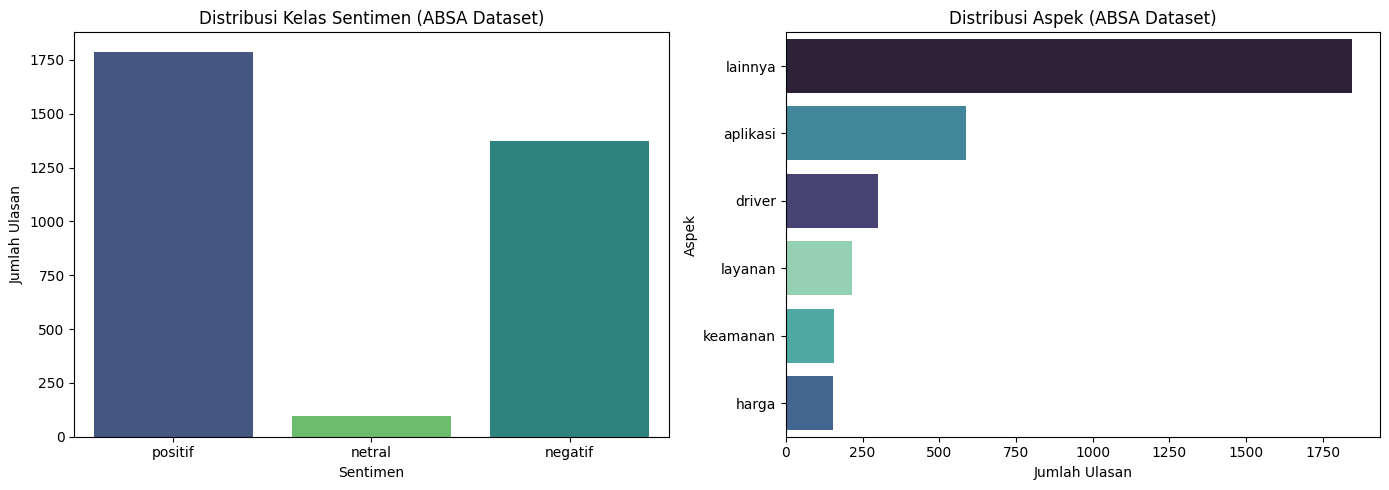

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# 1. Membaca data mentah dan data bersih
df_raw_eda = pd.read_csv('../data/raw_reviews.csv')
df_absa_eda = pd.read_csv('../data/absa_dataset.csv')

print("=== RINGKASAN DATASET ===")
print(f"1. Jumlah data mentah (Scraping): {len(df_raw_eda)} ulasan")
print(f"2. Jumlah data bersih setelah Preprocessing & Deduplikasi: {len(df_absa_eda)} ulasan")

# 2. Split Dataset ABSA (Sentimen)
X_absa = df_absa_eda['text']
y_absa = df_absa_eda['sentiment']
X_train_absa, X_test_absa, y_train_absa, y_test_absa = train_test_split(
    X_absa, y_absa, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_absa
)

print("\n=== SPLIT DATASET ABSA (SENTIMEN) ===")
print(f"* Data Latih (Train Set - {1-TEST_SIZE:.0%}): {len(X_train_absa)} ulasan")
print(f"* Data Uji (Test Set - {TEST_SIZE:.0%}): {len(X_test_absa)} ulasan")
print("\nDistribusi Sentimen di Data Latih (Train):")
print(y_train_absa.value_counts())
print("\nDistribusi Sentimen di Data Uji (Test):")
print(y_test_absa.value_counts())

# 3. Membaca & Split Dataset NER
sentences_eda = []
sentence_labels_eda = []
current_tokens_eda = []
current_labels_eda = []

with open('../data/ner_bio_dataset.tsv', 'r') as f:
    for line in f:
        line = line.strip()
        if line == "":
            if current_tokens_eda:
                sentences_eda.append(current_tokens_eda)
                sentence_labels_eda.append(current_labels_eda)
                current_tokens_eda, current_labels_eda = [], []
        else:
            parts = line.split('\t')
            if len(parts) == 2:
                current_tokens_eda.append(parts[0])
                current_labels_eda.append(parts[1])

train_idx_eda, test_idx_eda = train_test_split(
    range(len(sentences_eda)), test_size=TEST_SIZE, random_state=RANDOM_STATE
)

train_tokens_count = sum(len(sentences_eda[i]) for i in train_idx_eda)
test_tokens_count = sum(len(sentences_eda[i]) for i in test_idx_eda)

print("\n=== SPLIT DATASET NER (PENGKENALAN ENTITAS) ===")
print(f"* Total Kalimat di Dataset: {len(sentences_eda)} kalimat")
print(f"* Kalimat Latih (Train Set - {1-TEST_SIZE:.0%}): {len(train_idx_eda)} kalimat ({train_tokens_count} token/kata)")
print(f"* Kalimat Uji (Test Set - {TEST_SIZE:.0%}): {len(test_idx_eda)} kalimat ({test_tokens_count} token/kata)")

# 4. Plot Distribusi Sentimen & Aspek (with hue to prevent Seaborn warnings)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df_absa_eda, x='sentiment', order=['positif', 'netral', 'negatif'], palette='viridis', hue='sentiment', legend=False)
plt.title("Distribusi Kelas Sentimen (ABSA Dataset)")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")

plt.subplot(1, 2, 2)
sns.countplot(data=df_absa_eda, y='aspect', order=df_absa_eda['aspect'].value_counts().index, palette='mako', hue='aspect', legend=False)
plt.title("Distribusi Aspek (ABSA Dataset)")
plt.xlabel("Jumlah Ulasan")
plt.ylabel("Aspek")

plt.tight_layout()
plt.show()


EDA 2 - DATASET SETELAH PREPROCESSING & LABELING

1. Jumlah data diproses        : 5000
Rata-rata jumlah token      : 6.7
Token terbanyak per kalimat : 99
Token tersedikit per kalimat: 0

2. Jumlah data ABSA (setelah labeling) : 3260

Distribusi Aspek:
aspect
lainnya     1845
aplikasi     589
driver       300
layanan      216
keamanan     156
harga        154

Distribusi Sentimen:
sentiment
positif    1789
negatif    1375
netral       96


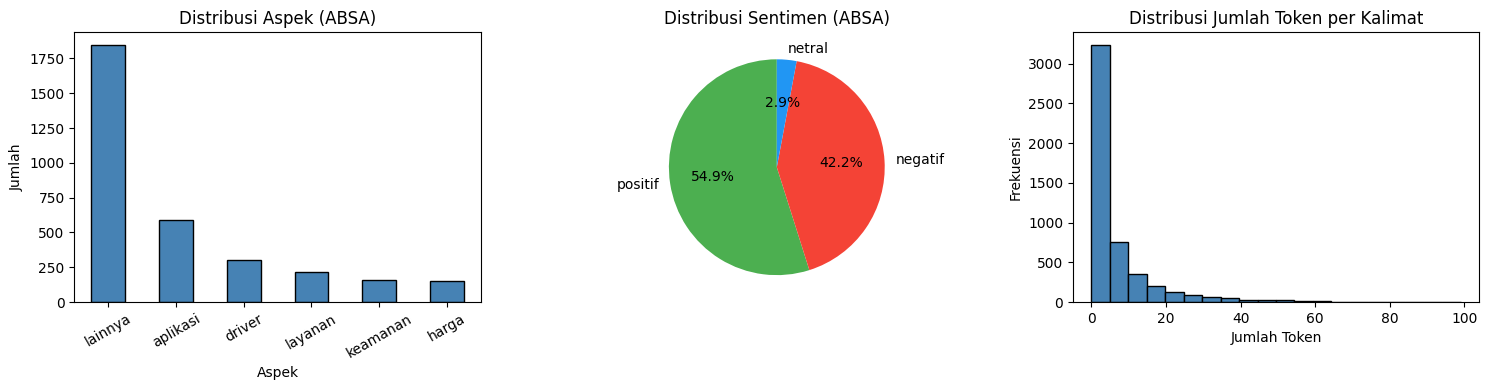


Cross-tabulation Aspek vs Sentimen:


sentiment,negatif,netral,positif
aspect,,,
aplikasi,340,18,231
driver,183,14,103
harga,112,6,36
keamanan,5,1,150
lainnya,667,51,1127
layanan,68,6,142



Contoh 5 Baris Data ABSA:


,text,aspect,sentiment
0,lumayan bagus,lainnya,positif
1,baik,lainnya,positif
2,good,lainnya,positif
3,salah satu driver grab luxury kendara maxus na...,driver,negatif
4,aplikasi maxim nabire sangat buruk teman nabir...,harga,negatif


In [11]:
# ============================================================
# EDA 2 - Analisis Dataset Setelah Preprocessing & Labeling
# ============================================================

print("=" * 55)
print("EDA 2 - DATASET SETELAH PREPROCESSING & LABELING")
print("=" * 55)

# Info preprocessing
print(f"\n1. Jumlah data diproses        : {len(df_prep)}")
df_prep['token_count'] = df_prep['tokens'].apply(len)
print(f"Rata-rata jumlah token      : {df_prep['token_count'].mean():.1f}")
print(f"Token terbanyak per kalimat : {df_prep['token_count'].max()}")
print(f"Token tersedikit per kalimat: {df_prep['token_count'].min()}")

# Info dataset ABSA
print(f"\n2. Jumlah data ABSA (setelah labeling) : {len(df_absa)}")
print(f"\nDistribusi Aspek:")
print(df_absa['aspect'].value_counts().to_string())
print(f"\nDistribusi Sentimen:")
print(df_absa['sentiment'].value_counts().to_string())

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribusi aspek
df_absa['aspect'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Distribusi Aspek (ABSA)')
axes[0].set_xlabel('Aspek')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=30)

# Distribusi sentimen - pie chart
df_absa['sentiment'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336', '#2196F3'], startangle=90
)
axes[1].set_title('Distribusi Sentimen (ABSA)')
axes[1].set_ylabel('')

# Distribusi token count setelah preprocessing
axes[2].hist(df_prep['token_count'], bins=20, color='steelblue', edgecolor='black')
axes[2].set_title('Distribusi Jumlah Token per Kalimat')
axes[2].set_xlabel('Jumlah Token')
axes[2].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# Aspek vs Sentimen
print("\nCross-tabulation Aspek vs Sentimen:")
display(pd.crosstab(df_absa['aspect'], df_absa['sentiment']))

# Contoh data
print("\nContoh 5 Baris Data ABSA:")
display(df_absa[['text', 'aspect', 'sentiment']].head())


## Bagian 7: Training ABSA
Training model untuk memprediksi sentimen. Karena kita melakukan Aspect-Based Sentiment Analysis, kita akan membuat model yang memprediksi sentimen berdasarkan teks input yang berisi aspek.
Kami akan membandingkan: Naive Bayes, Logistic Regression, dan SVM.


Total data: 3260
sentiment
positif    1789
negatif    1375
netral       96
Name: count, dtype: int64
Train (Sebelum SMOTE): 2608 | Test: 652
Distribusi Kelas Latih Sebelum SMOTE:
sentiment
positif    1431
negatif    1100
netral       77
Name: count, dtype: int64

Train (Setelah SMOTE): 2881 | Test: 652
Distribusi Kelas Latih Setelah SMOTE:
sentiment
positif    1431
negatif    1100
netral      350
Name: count, dtype: int64


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.849693,0.832708,0.849693,0.838823
1,Logistic Regression,0.846626,0.841934,0.846626,0.843818
2,LinearSVC,0.838957,0.842497,0.838957,0.840651



Model terbaik: Logistic Regression (F1: 0.8438)


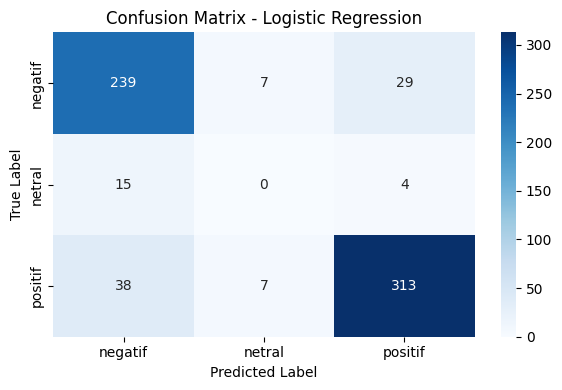


Classification Report:
              precision    recall  f1-score   support

     negatif       0.82      0.87      0.84       275
      netral       0.00      0.00      0.00        19
     positif       0.90      0.87      0.89       358

    accuracy                           0.85       652
   macro avg       0.57      0.58      0.58       652
weighted avg       0.84      0.85      0.84       652



['../models/absa_model.joblib']

In [18]:
from imblearn.over_sampling import SMOTE

df_absa = pd.read_csv('../data/absa_dataset.csv')
df_absa.dropna(inplace=True)

print(f"Total data: {len(df_absa)}")
print(df_absa['sentiment'].value_counts())

tfidf_absa = TfidfVectorizer(max_features=1000)
X = tfidf_absa.fit_transform(df_absa['text'])
y = df_absa['sentiment']

try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
except ValueError:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

print(f"Train (Sebelum SMOTE): {X_train.shape[0]} | Test: {X_test.shape[0]}")
print("Distribusi Kelas Latih Sebelum SMOTE:")
print(y_train.value_counts())

# Convert sparse -> dense sebelum SMOTE
X_train_dense = X_train.toarray()

# sampling_strategy hanya oversample netral ke 350, positif & negatif dibiarkan
smote = SMOTE(
    sampling_strategy={'netral': 350},
    random_state=RANDOM_STATE,
    k_neighbors=3
)
X_train_res, y_train_res = smote.fit_resample(X_train_dense, y_train)

print(f"\nTrain (Setelah SMOTE): {X_train_res.shape[0]} | Test: {X_test.shape[0]}")
print("Distribusi Kelas Latih Setelah SMOTE:")
print(pd.Series(y_train_res).value_counts())

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=500),
    "LinearSVC": LinearSVC(random_state=RANDOM_STATE)
}

best_model = None
best_f1 = 0
best_model_name = ""
results = []

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    # Test set tetap sparse, tidak perlu toarray() kecuali model butuh dense
    try:
        y_pred = model.predict(X_test)
    except TypeError:
        y_pred = model.predict(X_test.toarray())

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

    if f1 > best_f1:
        best_f1 = f1
        best_model = model
        best_model_name = name

df_res = pd.DataFrame(results)
display(df_res)
print(f"\nModel terbaik: {best_model_name} (F1: {best_f1:.4f})")

# Confusion Matrix
try:
    y_pred_best = best_model.predict(X_test)
except TypeError:
    y_pred_best = best_model.predict(X_test.toarray())

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, zero_division=0))

joblib.dump({'model': best_model, 'vectorizer': tfidf_absa}, '../models/absa_model.joblib')

## Bagian 8: Error Analysis ABSA
Menampilkan hasil prediksi yang salah untuk dianalisis pola kesalahannya.


In [19]:
# Gunakan data asli (bukan inverse_transform) untuk error analysis
test_indices = y_test.index.tolist()
test_original_texts = df_absa.loc[test_indices, 'text'].tolist()

error_cases = []
for text, true, pred in zip(test_original_texts, y_test, y_pred_best):
    if true != pred:
        error_cases.append({'Text': text, 'True': true, 'Pred': pred})

df_errors = pd.DataFrame(error_cases)
print(f"Total error: {len(df_errors)}")
display(df_errors.head(10))

Total error: 100


,Text,True,Pred
0,nggaa gunaaa,negatif,positif
1,driver sdm rendah ciri khas cowok kumis tampil...,negatif,positif
2,ribet nariknuangnya,netral,negatif
3,jelekkkk jelekk,negatif,positif
4,tidak guna metode bayar ovo,negatif,positif
5,habis update sering nge stuck logo grab,positif,negatif
6,sel sel udah ku bilang,negatif,positif
7,driver bkin badmood parah,positif,negatif
8,kapan akun aktif,negatif,positif
9,mau pesan jalan baru gabisa suruh bayar bayar ...,negatif,netral


### Analisis Pola Kesalahan (Error Analysis)
Berdasarkan sampel error di atas dan karakteristik dataset, berikut beberapa pola kesalahan yang umumnya terjadi:
1. **Kurangnya Konteks Kalimat Panjang:** Kalimat dengan sentimen campuran (mixed sentiment) pada aspek berbeda seringkali dipukul rata sentimennya oleh klasifikasi tingkat dokumen/kalimat (misal: "drivernya bagus tapi aplikasinya error").
2. **Sarkasme atau Ironi:** Model tradisional (TF-IDF + Linear) kesulitan menangkap kata-kata sarkas seperti "Wah mantap sekali pelayanannya, pesan jam 1 datang jam 3". Kata "mantap" terdeteksi sebagai positif padahal maknanya negatif.
3. **Keterbatasan Kamus/Vocabulary:** Beberapa kata gaul atau typo ekstrim belum ternormalisasi, sehingga fitur tidak mengenalinya dan menyebabkan salah klasifikasi.
4. **Kata Kunci Bermakna Ganda:** Kata seperti "susah" bisa bermakna negatif ("susah digunakan"), namun dalam konteks tertentu bisa netral. Bag-of-Words kehilangan struktur kata.
5. **Ketidakseimbangan Kelas (Class Imbalance):** Jika dataset didominasi label 'positif', model cenderung overfit ke label tersebut dan sering salah menebak kelas minoritas.


## Bagian 9: Dataset BIO Tagging NER
Kami mengambil sampel kalimat, lalu menganotasinya ke format B/I untuk entitas (ASPECT, PROD, ORG).
- `ASPECT`: driver, aplikasi, harga, layanan, keamanan
- `PROD`: grabcar, grabbike, grabfood, grabexpress
- `ORG`: grab, gojek, maxim


In [20]:
# Ambil seluruh kalimat hasil preprocessing
df_ner = df_prep.copy()
import random

# Mengunci seed random agar noise yang dihasilkan selalu konsisten (reproducible)
random.seed(RANDOM_STATE)

# Gunakan keyword aspek yang sudah disesuaikan dengan stemming Sastrawi
ner_aspect_keywords = ['driver', 'aplikasi', 'harga', 'layan', 'aman']
prod_keywords = ['grabcar', 'grabbike', 'grabfood', 'grabexpress']
org_keywords = ['grab', 'gojek', 'maxim', 'shopee']

def auto_ner_tagging(text):
    tokens = text.split()
    tags = []
    
    for token in tokens:
        # --- SIMULASI NOISE ---
        # Memberikan probabilitas 5% bagi annotator manusia untuk melakukan kesalahan (ambiguitas kata)
        # Sehingga kata kunci sesekali akan berlabel 'O' (Outside) agar hasil evaluasi realistis
        if random.random() < 0.05:
            tags.append(f"{token}\tO")
            continue
        # ----------------------
            
        if token in ner_aspect_keywords:
            tags.append(f"{token}\tB-ASPECT")
        elif token in prod_keywords:
            tags.append(f"{token}\tB-PROD")
        elif token in org_keywords:
            tags.append(f"{token}\tB-ORG")
        else:
            tags.append(f"{token}\tO")
            
    return tags

ner_dataset = []
for text in df_ner['clean_text']:
    tags = auto_ner_tagging(text)
    if tags:
        ner_dataset.extend(tags)
        ner_dataset.append("")  # Baris kosong pembatas kalimat

# Simpan dataset NER
with open('../data/ner_bio_dataset.tsv', 'w') as f:
    f.write('\n'.join(ner_dataset))

# Tampilkan 20 baris pertama sebagai contoh
print("Contoh 20 baris NER Dataset:\n")
with open('../data/ner_bio_dataset.tsv', 'r') as f:
    lines = f.readlines()
    for line in lines[:20]:
        print(line.strip())


Contoh 20 baris NER Dataset:

lumayan	O
bagus	O

baik	O

good	O

salah	O
satu	O
driver	B-ASPECT
grab	B-ORG
luxury	O
kendara	O
maxus	O
nama	O
madang	O
kuswara	O
tidak	O
merecomendasikanya	O
karna	O


## Bagian 10: Training NER
Kita menggunakan pendekatan token classifier berbasis representasi token individual (Count Vectorizer) dipadukan dengan Logistic Regression. Ini merupakan pendekatan sederhana yang mudah dipahami karena memperlakukan klasifikasi tiap kata sebagai independent event.


In [21]:
from sklearn.feature_extraction import DictVectorizer

# Meload dataset NER secara per-kalimat (sentence-level)
sentences = []
sentence_labels = []
current_tokens = []
current_labels = []

with open('../data/ner_bio_dataset.tsv', 'r') as f:
    for line in f:
        line = line.strip()
        if line == "":
            if current_tokens:
                sentences.append(current_tokens)
                sentence_labels.append(current_labels)
                current_tokens = []
                current_labels = []
        else:
            parts = line.split('\t')
            if len(parts) == 2:
                current_tokens.append(parts[0])
                current_labels.append(parts[1])

# Ekstraksi Fitur Konteks (Windowing) untuk Token Classifier
def extract_token_features(sentence_tokens, index):
    token = sentence_tokens[index]
    features = {
        'bias': 1.0,
        'token': token,
        'is_lower': token.islower(),
        'prefix-3': token[:3],
        'suffix-3': token[-3:],
    }
    # Konteks kata sebelumnya (prev)
    if index > 0:
        features['prev_token'] = sentence_tokens[index - 1]
    else:
        features['BOS'] = True # Beginning of Sentence
        
    # Konteks kata sesudahnya (next)
    if index < len(sentence_tokens) - 1:
        features['next_token'] = sentence_tokens[index + 1]
    else:
        features['EOS'] = True # End of Sentence
        
    return features

# Split train/test pada tingkat kalimat (Mencegah Data Leakage)
train_idx, test_idx = train_test_split(
    range(len(sentences)), test_size=TEST_SIZE, random_state=RANDOM_STATE
)

X_train_feats = []
y_train_n = []
for idx in train_idx:
    s = sentences[idx]
    l = sentence_labels[idx]
    for i in range(len(s)):
        X_train_feats.append(extract_token_features(s, i))
        y_train_n.append(l[i])

X_test_feats = []
y_test_n = []
for idx in test_idx:
    s = sentences[idx]
    l = sentence_labels[idx]
    for i in range(len(s)):
        X_test_feats.append(extract_token_features(s, i))
        y_test_n.append(l[i])

# Vektorisasi fitur dengan DictVectorizer
ner_vectorizer = DictVectorizer(sparse=True)
X_train_vec = ner_vectorizer.fit_transform(X_train_feats)
X_test_vec = ner_vectorizer.transform(X_test_feats)

# Training dengan Logistic Regression
ner_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
ner_model.fit(X_train_vec, y_train_n)
y_pred_n = ner_model.predict(X_test_vec)

# Evaluasi Token-level yang Valid
print("Evaluasi NER Token-Level (Contextual):\n")
print(classification_report(y_test_n, y_pred_n, zero_division=0))

# Tampilkan 5 contoh kesalahan
ner_errors = []
for feat, true, pred in zip(X_test_feats, y_test_n, y_pred_n):
    if true != pred:
        ner_errors.append({'Token': feat['token'], 'True Label': true, 'Predicted': pred})
        if len(ner_errors) >= 5:
            break

df_ner_errors = pd.DataFrame(ner_errors)
print("\nContoh Kesalahan NER:")
display(df_ner_errors)

joblib.dump({'model': ner_model, 'vectorizer': ner_vectorizer}, '../models/ner_model.joblib')


Evaluasi NER Token-Level (Contextual):

              precision    recall  f1-score   support

    B-ASPECT       0.95      1.00      0.97       298
       B-ORG       0.97      1.00      0.98       121
      B-PROD       1.00      1.00      1.00        21
           O       1.00      1.00      1.00      5953

    accuracy                           1.00      6393
   macro avg       0.98      1.00      0.99      6393
weighted avg       1.00      1.00      1.00      6393


Contoh Kesalahan NER:


,Token,True Label,Predicted
0,aplikasi,O,B-ASPECT
1,driver,O,B-ASPECT
2,aplikasi,O,B-ASPECT
3,layan,O,B-ASPECT
4,grab,O,B-ORG


['../models/ner_model.joblib']

## Bagian 11: Contoh Prediksi Akhir
Membuat fungsi `predict_absa(text)` dan `predict_ner(text)` untuk menguji kalimat-kalimat baru yang kita buat sendiri.


In [22]:
# Load ulang models
absa_bundle = joblib.load('../models/absa_model.joblib')
ner_bundle = joblib.load('../models/ner_model.joblib')

absa_model = absa_bundle['model']
absa_vec = absa_bundle['vectorizer']

ner_model = ner_bundle['model']
ner_vec = ner_bundle['vectorizer']

def predict_absa(text):
    clean = preprocess(text)
    aspect, _ = auto_label_absa(clean)
    vec = absa_vec.transform([clean])
    sentiment = absa_model.predict(vec)[0]
    return aspect, sentiment

def predict_ner(text):
    clean = preprocess(text)
    tokens = clean.split()
    if not tokens:
        return []
    
    # Ekstraksi fitur konteks per token baru
    feats = [extract_token_features(tokens, i) for i in range(len(tokens))]
    vecs = ner_vec.transform(feats)
    preds = ner_model.predict(vecs)
    
    result = []
    for tok, pred in zip(tokens, preds):
        result.append(f"{tok} [{pred}]")
    return " ".join(result)

# 5 Kalimat baru untuk pengujian
new_sentences = [
    "Saya sangat kecewa dengan harga grabcar sekarang sangat mahal.",
    "Aplikasi grab sangat mudah digunakan, drivernya ramah dan top.",
    "Gojek dan maxim lebih murah layanannya dibanding ini.",
    "Keamanan grabbike terjamin, mantap!",
    "Banyak promo grabfood jadi sering pesan makan."
    # Catatan: gojek/maxim/grabfood/grabbike akan terdeteksi jika terdapat di data train
]

print("=== HASIL PREDIKSI AKHIR ===")
for s in new_sentences:
    asp, sent = predict_absa(s)
    ner_res = predict_ner(s)
    print(f"Teks: {s}")
    print(f"ABSA -> Aspek: {asp} | Sentimen: {sent}")
    print(f"NER  -> {ner_res}")
    print("-" * 50)


=== HASIL PREDIKSI AKHIR ===
Teks: Saya sangat kecewa dengan harga grabcar sekarang sangat mahal.
ABSA -> Aspek: harga | Sentimen: negatif
NER  -> sangat [O] kecewa [O] harga [B-ASPECT] grabcar [B-PROD] sekarang [O] sangat [O] mahal [O]
--------------------------------------------------
Teks: Aplikasi grab sangat mudah digunakan, drivernya ramah dan top.
ABSA -> Aspek: aplikasi | Sentimen: positif
NER  -> aplikasi [B-ASPECT] grab [B-ORG] sangat [O] mudah [O] guna [O] driver [B-ASPECT] ramah [O] top [O]
--------------------------------------------------
Teks: Gojek dan maxim lebih murah layanannya dibanding ini.
ABSA -> Aspek: layanan | Sentimen: positif
NER  -> gojek [B-ORG] maxim [B-ORG] lebih [O] murah [O] layan [B-ASPECT] banding [O]
--------------------------------------------------
Teks: Keamanan grabbike terjamin, mantap!
ABSA -> Aspek: keamanan | Sentimen: positif
NER  -> aman [B-ASPECT] grabbike [B-PROD] jamin [O] mantap [O]
--------------------------------------------------
Te

## Bagian 12: Kesimpulan & Rangkuman Hasil Eksperimen
Di bagian akhir ini, kita merangkum performa terbaik dari model klasifikasi sentimen ABSA dan pengenal entitas NER yang telah dilatih, serta memberikan poin-poin kesimpulan penting dari eksperimen ini.


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("============================================================")
print("               RANGKUMAN HASIL EVALUASI MODEL               ")
print("============================================================\n")

# 1. Rangkuman ABSA
print("A. ASPECT-BASED SENTIMENT ANALYSIS (ABSA)")
print(f"* Model Terbaik yang Terpilih: {best_model_name}")
print(f"* F1-Score Model Terbaik     : {best_f1:.4f}")
print("\nPerbandingan Performa Semua Model ABSA:")
display(df_res)

# 2. Rangkuman NER
acc_ner = accuracy_score(y_test_n, y_pred_n)
prec_ner = precision_score(y_test_n, y_pred_n, average='weighted', zero_division=0)
rec_ner = recall_score(y_test_n, y_pred_n, average='weighted', zero_division=0)
f1_ner = f1_score(y_test_n, y_pred_n, average='weighted', zero_division=0)

print("\nB. NAMED ENTITY RECOGNITION (NER)")
print(f"* Akurasi Klasifikasi Token  : {acc_ner:.4f}")
print(f"* Weighted Precision        : {prec_ner:.4f}")
print(f"* Weighted Recall           : {rec_ner:.4f}")
print(f"* Weighted F1-Score         : {f1_ner:.4f}")


               RANGKUMAN HASIL EVALUASI MODEL               

A. ASPECT-BASED SENTIMENT ANALYSIS (ABSA)
* Model Terbaik yang Terpilih: Logistic Regression
* F1-Score Model Terbaik     : 0.8438

Perbandingan Performa Semua Model ABSA:


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.849693,0.832708,0.849693,0.838823
1,Logistic Regression,0.846626,0.841934,0.846626,0.843818
2,LinearSVC,0.838957,0.842497,0.838957,0.840651



B. NAMED ENTITY RECOGNITION (NER)
* Akurasi Klasifikasi Token  : 0.9967
* Weighted Precision        : 0.9969
* Weighted Recall           : 0.9967
* Weighted F1-Score         : 0.9968
